# Exploratory Data Analysis

## Libraries

In [3]:
from pathlib import Path
from typing import Union, Tuple, Dict, Any

import os
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="white", context="talk")

import PIL
import SimpleITK as sitk
import gzip
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

from tqdm import tqdm

# Getting rid of warnings
import warnings
warnings.filterwarnings("ignore")
sitk.ProcessObject.SetGlobalWarningDisplay(False)

## Configuration

In [4]:
current_dir = os.getcwd()

# Define paths relative to the 'notebooks' folder by going up one level ('..')
project_root = os.path.join(current_dir, "..")
training_data = os.path.join(project_root, "data", "raw", "training")
testing_data = os.path.join(project_root, "data", "raw", "testing")

# Verify
print(f"Training data located at: {os.path.abspath(training_data)}")

Training data located at: /Users/cankucukyilmaz/Desktop/dl_for_3D_medical_image_analysis/project/data/raw/training


## Helper Functions

In [15]:
def display_content(base_path, patient_id):
    """
    Displays the content of a patient's folder.

    Constructs the folder name using the patient ID and lists all files 
    contained within that directory if it exists.

    Args:
        base_path (str): The root directory path containing the patient folders.
        patient_id (int): The unique integer identifier of the patient (will be formatted as 'patientXXX').
    """
    patient_folder = f"patient{patient_id:03d}"
    full_path = os.path.join(base_path, patient_folder)
    
    if os.path.exists(full_path):
        files = os.listdir(full_path)
        print(f"Contents of {patient_folder}:")
        for f in files:
            print(f" - {f}")
    else:
        print(f"Error: Path not found - {full_path}")

def display_patient_metadata(base_path, patient_id):
    """
    Reads and displays specific metadata files for a patient.

    Scans the patient's directory for configuration (.cfg) and markdown (.md) 
    files, and prints their contents with formatted headers.

    Args:
        base_path (str): The root directory path containing the patient folders.
        patient_id (int): The unique integer identifier of the patient.
    """
    patient_folder = f"patient{patient_id:03d}"
    full_path = os.path.join(base_path, patient_folder)

    if not os.path.exists(full_path):
        print(f"Error: Path not found - {full_path}")
        return

    files = sorted([f for f in os.listdir(full_path) if f.endswith(('.cfg', '.md'))])
    
    if not files:
        print(f"No metadata (.cfg or .md) found in {patient_folder}")
        return

    for filename in files:
        file_path = os.path.join(full_path, filename)
        
        label = "CONFIG" if filename.endswith('.cfg') else "MARKDOWN"
        
        try:
            with open(file_path, 'r') as f:
                content = f.read()
            
            # Clear visual separation
            print(f"\n--- {label}: {filename} ---")
            print(content.strip())
            print("-" * 30)
            
        except Exception as e:
            print(f"Error reading {filename}: {e}")

def analyze_patient_groups(base_path):
    """
    Iterates through all patient folders, reads 'Info.cfg', and 
    extracts the disease group (NOR, MINF, DCM, HCM, RV).
    
    Returns:
        pd.DataFrame: A summary of counts per group.
    """
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} does not exist.")
        return pd.DataFrame()

    patient_data = []
    patient_folders = sorted([d for d in os.listdir(base_path) if d.startswith("patient")])

    for p_folder in tqdm(patient_folders, desc="Reading Patient Groups"):
        cfg_path = os.path.join(base_path, p_folder, "Info.cfg")
        
        if os.path.exists(cfg_path):
            try:
                with open(cfg_path, 'r') as f:
                    for line in f:
                        if line.startswith("Group:"):
                            # Extract value after 'Group:' and strip whitespace
                            group = line.split(":")[1].strip()
                            patient_data.append({"Patient": p_folder, "Group": group})
                            break
            except Exception as e:
                print(f"Error reading {cfg_path}: {e}")
        else:
            print(f"Warning: No Info.cfg found for {p_folder}")

    # Create DataFrame
    df = pd.DataFrame(patient_data)
    
    if df.empty:
        print("No group data found.")
        return pd.DataFrame()

    # Calculate Statistics
    summary = df['Group'].value_counts().reset_index()
    summary.columns = ['Group', 'Count']
    summary['Percentage'] = (summary['Count'] / summary['Count'].sum()) * 100

    # Visualization
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Group', y='Count', data=summary, palette='viridis')
    plt.title(f"Patient Distribution by Disease Group (N={len(df)})")
    plt.ylabel("Number of Patients")
    plt.xlabel("Disease Group")
    
    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')
    
    plt.show()
    
    return summary

def sitk_load(filepath: Union[str, Path]) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Loads an image using SimpleITK and returns the image and its metadata.
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None, None

    # Load image
    image = sitk.ReadImage(str(filepath))
    
    # Extract metadata
    info = {
        "origin": image.GetOrigin(), 
        "spacing": image.GetSpacing(), 
        "direction": image.GetDirection()
    }

    # Extract numpy array (SimpleITK order is x,y,z -> numpy is z,y,x)
    im_array = np.squeeze(sitk.GetArrayFromImage(image))

    return im_array, info

def visualize_patient_data(base_path, patient_id):
    """
    Automatically finds and visualizes all .nii.gz files for a given patient.
    
    - SAVES outputs to: PROJECT_ROOT/visualizations (../visualizations)
    - FILENAMES: Prefixed with patient_id to prevent overwriting.
    - PLOT TITLES: Kept clean (original format).
    """
    patient_folder = f"patient{patient_id:03d}"
    full_path = os.path.join(base_path, patient_folder)
    
    # --- CHANGE: Output to project root relative to notebooks/ folder ---
    output_dir = "../visualizations"
    os.makedirs(output_dir, exist_ok=True)

    if not os.path.exists(full_path):
        print(f"Error: Path not found - {full_path}")
        return

    files = sorted([f for f in os.listdir(full_path) if f.endswith('.nii.gz')])
    
    if not files:
        print(f"No .nii.gz files found for {patient_folder}")
        return

    print(f"--- Processing {patient_folder} ---")
    print(f"Saving to: {os.path.abspath(output_dir)}")

    for filename in files:
        file_path = os.path.join(full_path, filename)
        
        # Load the file
        img, info = sitk_load(file_path)
        if img is None: continue

        ndim = img.ndim
        clean_fname = filename.replace('.nii.gz', '')
        
        # --- Visualization Logic ---
        if ndim == 3:
            mid_slice = img.shape[0] // 2
            
            # Original Title Logic
            is_gt = "_gt" in filename
            title = f"{filename} (Ground Truth)" if is_gt else f"{filename} (Ultrasound Frame)"
            cmap = 'jet' if is_gt else 'gray'
            
            plt.figure(figsize=(5, 5))
            plt.imshow(img[mid_slice], cmap=cmap)
            plt.title(title) # Keeping title clean
            plt.axis('off')
            
            # Save with Patient ID to avoid overwrites
            save_name = f"{patient_folder}_{clean_fname}_slice{mid_slice}.png"
            plt.savefig(os.path.join(output_dir, save_name), bbox_inches='tight', dpi=150)
            plt.close()

        elif ndim == 4:
            num_frames, num_slices, h, w = img.shape
            mid_slice = num_slices // 2
            
            print(f"Generating animation for {filename}...")
            
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.axis('off')
            im_display = ax.imshow(img[0][mid_slice], cmap='gray')
            ax.set_title(f"{filename} (4D Sequence)") # Keeping title clean

            def update(i):
                im_display.set_array(img[i][mid_slice])
                return [im_display]

            anim = FuncAnimation(fig, update, frames=num_frames, interval=80, blit=True)
            
            # Save with Patient ID
            save_name = f"{patient_folder}_{clean_fname}.gif"
            try:
                anim.save(os.path.join(output_dir, save_name), writer=PillowWriter(fps=15))
            except Exception as e:
                print(f"Error saving {save_name}: {e}")
            
            plt.close()
            
    print(f"Done. Files saved to {output_dir}/")

def audit_all_shapes(base_path):
    """
    Scans EVERY .nii.gz file (3D and 4D) to report dimensions.
    Uses a progress bar instead of printing lines.
    """
    stats = []
    
    # 1. Get all patient folders
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} does not exist.")
        return pd.DataFrame()

    patient_folders = sorted([d for d in os.listdir(base_path) if d.startswith("patient")])
    
    # We use a context manager (with) to ensure the bar closes properly
    with tqdm(patient_folders, unit="patient") as pbar:
        for p_folder in pbar:
            pbar.set_description(f"Scanning {p_folder}")
            
            full_path = os.path.join(base_path, p_folder)
            
            if not os.path.isdir(full_path): continue
            
            files = sorted([f for f in os.listdir(full_path) if f.endswith('.nii.gz')])
            
            for f in files:
                img_path = os.path.join(full_path, f)
                try:
                    # Read image
                    sitk_img = sitk.ReadImage(img_path)
                    
                    # Convert to numpy (Sitk is (W, H, D) -> numpy is (D, H, W) or (Time, D, H, W))
                    # Note: SimpleITK GetArrayFromImage reverses dimensions to numpy standard (z, y, x)
                    img_arr = sitk.GetArrayFromImage(sitk_img)
                    shape = img_arr.shape
                    ndim = img_arr.ndim
                    
                    # Logic to parse dimensions
                    # Numpy shape is typically (Time, Slices, Height, Width) for 4D
                    # or (Slices, Height, Width) for 3D
                    if ndim == 4:
                        frames, depth, h, w = shape
                        type_str = "4D Video"
                    elif ndim == 3:
                        depth, h, w = shape
                        frames = 1
                        type_str = "3D Vol"
                    else:
                        # Fallback for unexpected shapes
                        frames, depth, h, w = (0, 0, 0, 0)
                        if ndim == 2: h, w = shape
                        type_str = f"{ndim}D Unknown"

                    # Store data
                    stats.append({
                        "Patient": p_folder,
                        "File": f,
                        "Type": type_str,
                        "Frames (Time)": frames,
                        "Slices (Depth)": depth,
                        "Height": h,
                        "Width": w
                    })
                    
                except Exception as e:
                    pbar.write(f"Error reading {f}: {e}")

    return pd.DataFrame(stats)

def analyze_dimension_variance(df):
    """
    Analyzes the diversity of image shapes within each 'Type' group.
    Now includes Min/Max statistics.
    """
    if df.empty:
        print("No data to analyze.")
        return

    print("--- 1. Independent Variance (Unique Values) ---")
    independent_counts = df.groupby('Type')[['Height', 'Width']].nunique()
    print(independent_counts)
    
    print("\n--- 2. Dimension Range (Min / Max) ---")
    # This aggregates min and max for both Height and Width columns
    ranges = df.groupby('Type')[['Height', 'Width']].agg(['min', 'max'])
    print(ranges)

    print("\n--- 3. Resolution Variance (Unique Shape Pairs) ---")
    df['Resolution'] = list(zip(df['Height'], df['Width']))
    unique_resolutions = df.groupby('Type')['Resolution'].unique()
    
    for type_name, res_list in unique_resolutions.items():
        print(f"\nType: {type_name} ({len(res_list)} unique resolutions)")
        # Sort them for cleaner viewing
        sorted_res = sorted(res_list)
        for r in sorted_res:
            print(f"  - {r[0]} x {r[1]}")

## What do we have in our data?

In [12]:
display_content(training_data, 1)

Contents of patient001:
 - Info.cfg
 - patient001_frame01.nii.gz
 - MANDATORY_CITATION.md
 - patient001_frame12.nii.gz
 - patient001_frame12_gt.nii.gz
 - patient001_frame01_gt.nii.gz
 - patient001_4d.nii.gz


In [9]:
# .cfg      configuration
# .nii.gz   neuroimaging informatics technology initiative as gzip compression
# .md       markdown

In [6]:
display_content(training_data, 3)

Contents of patient003:
 - Info.cfg
 - patient003_frame15.nii.gz
 - patient003_frame01.nii.gz
 - MANDATORY_CITATION.md
 - patient003_4d.nii.gz
 - patient003_frame01_gt.nii.gz
 - patient003_frame15_gt.nii.gz


In [11]:
# patient001 has frame01 and frame12
# patient003 has frame01 and frame15

# different patients have different numbers after "frame"

In [7]:
display_content(testing_data, 101)

Contents of patient101:
 - Info.cfg
 - patient101_4d.nii.gz
 - MANDATORY_CITATION.md
 - patient101_frame01.nii.gz
 - patient101_frame14_gt.nii.gz
 - patient101_frame14.nii.gz
 - patient101_frame01_gt.nii.gz


In [8]:
display_content(testing_data, 103)

Contents of patient103:
 - Info.cfg
 - patient103_frame01.nii.gz
 - patient103_frame11_gt.nii.gz
 - patient103_frame11.nii.gz
 - MANDATORY_CITATION.md
 - patient103_frame01_gt.nii.gz
 - patient103_4d.nii.gz


In [14]:
# Same things apply for the test data

### Info.cfg & MANDATORY_CITATION.md

In [9]:
display_patient_metadata(training_data, 1)


--- CONFIG: Info.cfg ---
ED: 1
ES: 12
Group: DCM
Height: 184.0
NbFrame: 30
Weight: 95.0
------------------------------

--- MARKDOWN: MANDATORY_CITATION.md ---
You have to refer to this citation for any use of the ACDC database

O. Bernard, A. Lalande, C. Zotti, F. Cervenansky, et al.
"Deep Learning Techniques for Automatic MRI Cardiac Multi-structures Segmentation and Diagnosis: Is the Problem Solved ?" in IEEE Transactions on Medical Imaging, vol. 37, no. 11, pp. 2514-2525, Nov. 2018
doi: 10.1109/TMI.2018.2837502
------------------------------


In [ ]:
# Groups are present in Info.cfg

### Amount of groups and their cardinality

Reading Patient Groups: 100%|██████████| 100/100 [00:00<00:00, 4012.04it/s]


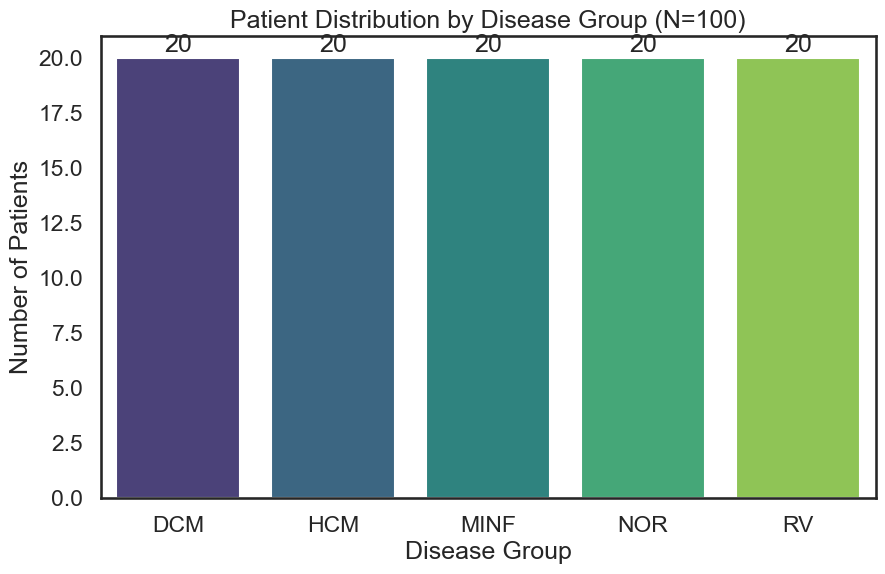

,Group,Count,Percentage
0,DCM,20,20.0
1,HCM,20,20.0
2,MINF,20,20.0
3,NOR,20,20.0
4,RV,20,20.0


In [10]:
group_stats = analyze_patient_groups(training_data)
display(group_stats)

Reading Patient Groups: 100%|██████████| 50/50 [00:00<00:00, 2701.09it/s]


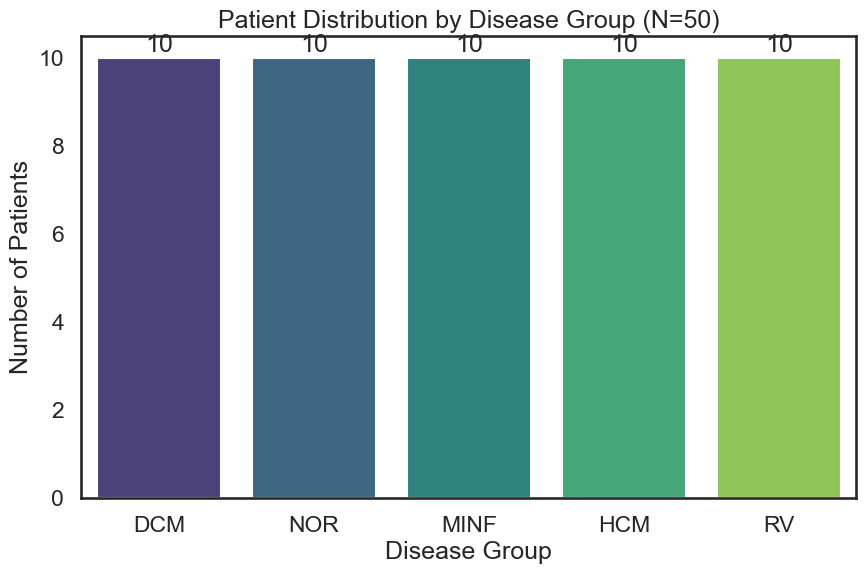

,Group,Count,Percentage
0,DCM,10,20.0
1,NOR,10,20.0
2,MINF,10,20.0
3,HCM,10,20.0
4,RV,10,20.0


In [11]:
group_stats = analyze_patient_groups(testing_data)
display(group_stats)

### 3D + 4D data visualization

In [16]:
# Visualize everything for Patient 1
visualize_patient_data(training_data, 83)

--- Processing patient083 ---
Saving to: /Users/cankucukyilmaz/Desktop/dl_for_3D_medical_image_analysis/project/visualizations
Generating animation for patient083_4d.nii.gz...
Done. Files saved to ../visualizations/


In [13]:
# gt stands for "ground truth"

## Statistics of our Data

### Training Data

In [22]:
train_data_spahes = audit_all_shapes(training_data)

Scanning patient100: 100%|██████████| 100/100 [00:15<00:00,  6.52patient/s]


In [23]:
display(train_data_spahes.head(10))

,Patient,File,Type,Frames (Time),Slices (Depth),Height,Width
0,patient001,patient001_4d.nii.gz,4D Video,30,10,256,216
1,patient001,patient001_frame01.nii.gz,3D Vol,1,10,256,216
2,patient001,patient001_frame01_gt.nii.gz,3D Vol,1,10,256,216
3,patient001,patient001_frame12.nii.gz,3D Vol,1,10,256,216
4,patient001,patient001_frame12_gt.nii.gz,3D Vol,1,10,256,216
5,patient002,patient002_4d.nii.gz,4D Video,30,10,256,232
6,patient002,patient002_frame01.nii.gz,3D Vol,1,10,256,232
7,patient002,patient002_frame01_gt.nii.gz,3D Vol,1,10,256,232
8,patient002,patient002_frame12.nii.gz,3D Vol,1,10,256,232
9,patient002,patient002_frame12_gt.nii.gz,3D Vol,1,10,256,232


In [24]:
analyze_dimension_variance(train_data_spahes)

--- 1. Independent Variance (Unique Values) ---
          Height  Width
Type                   
3D Vol        12     20
4D Video      12     20

--- 2. Dimension Range (Min / Max) ---
         Height      Width     
            min  max   min  max
Type                           
3D Vol      154  512   154  428
4D Video    154  512   154  428

--- 3. Resolution Variance (Unique Shape Pairs) ---

Type: 3D Vol (29 unique resolutions)
  - 154 x 224
  - 174 x 208
  - 176 x 256
  - 184 x 256
  - 208 x 174
  - 208 x 256
  - 216 x 256
  - 224 x 154
  - 224 x 168
  - 224 x 174
  - 224 x 180
  - 224 x 210
  - 224 x 222
  - 256 x 184
  - 256 x 192
  - 256 x 200
  - 256 x 208
  - 256 x 214
  - 256 x 216
  - 256 x 224
  - 256 x 232
  - 256 x 240
  - 256 x 248
  - 256 x 256
  - 288 x 184
  - 288 x 264
  - 304 x 216
  - 384 x 276
  - 512 x 428

Type: 4D Video (29 unique resolutions)
  - 154 x 224
  - 174 x 208
  - 176 x 256
  - 184 x 256
  - 208 x 174
  - 208 x 256
  - 216 x 256
  - 224 x 154
  - 224

### Test Data

In [25]:
test_data_spahes = audit_all_shapes(testing_data)

Scanning patient150: 100%|██████████| 50/50 [00:08<00:00,  6.07patient/s]


In [26]:
display(test_data_spahes.head(10))

,Patient,File,Type,Frames (Time),Slices (Depth),Height,Width
0,patient101,patient101_4d.nii.gz,4D Video,30,10,256,232
1,patient101,patient101_frame01.nii.gz,3D Vol,1,10,256,232
2,patient101,patient101_frame01_gt.nii.gz,3D Vol,1,10,256,232
3,patient101,patient101_frame14.nii.gz,3D Vol,1,10,256,232
4,patient101,patient101_frame14_gt.nii.gz,3D Vol,1,10,256,232
5,patient102,patient102_4d.nii.gz,4D Video,30,8,256,216
6,patient102,patient102_frame01.nii.gz,3D Vol,1,8,256,216
7,patient102,patient102_frame01_gt.nii.gz,3D Vol,1,8,256,216
8,patient102,patient102_frame13.nii.gz,3D Vol,1,8,256,216
9,patient102,patient102_frame13_gt.nii.gz,3D Vol,1,8,256,216


In [27]:
analyze_dimension_variance(test_data_spahes)

--- 1. Independent Variance (Unique Values) ---
          Height  Width
Type                   
3D Vol        11     14
4D Video      11     14

--- 2. Dimension Range (Min / Max) ---
         Height      Width     
            min  max   min  max
Type                           
3D Vol      162  288   154  256
4D Video    162  288   154  256

--- 3. Resolution Variance (Unique Shape Pairs) ---

Type: 3D Vol (21 unique resolutions)
  - 162 x 208
  - 166 x 240
  - 174 x 208
  - 180 x 224
  - 208 x 162
  - 208 x 168
  - 208 x 174
  - 214 x 256
  - 216 x 256
  - 224 x 154
  - 224 x 180
  - 232 x 256
  - 256 x 192
  - 256 x 208
  - 256 x 214
  - 256 x 216
  - 256 x 224
  - 256 x 232
  - 256 x 240
  - 256 x 248
  - 288 x 232

Type: 4D Video (21 unique resolutions)
  - 162 x 208
  - 166 x 240
  - 174 x 208
  - 180 x 224
  - 208 x 162
  - 208 x 168
  - 208 x 174
  - 214 x 256
  - 216 x 256
  - 224 x 154
  - 224 x 180
  - 232 x 256
  - 256 x 192
  - 256 x 208
  - 256 x 214
  - 256 x 216
  - 256

In [28]:
# We cannot crop or ad padding to these images due to memory and time constraints.
# Solution: Use U-Net

## Preprocessing